# Data Cleaning

In [2]:
import pandas as pd

# Load the CSV file
df = pd.read_csv("combined.csv")

# Columns to drop
columns_to_drop = [
    "source",
    "handle",
    "tags",
    "description_html",
    "variant_id",
    "variant_title",
    "compare_at_price",
    "discount_myr",
    "discount_pct",
    "published_at",
    "sku",
    "product_url",
    "available_text",
    "image_url"
]

# Drop columns
df = df.drop(columns=columns_to_drop, errors='ignore')

# Combine 'is_on_sale' and 'available' into one column
df["sale_available"] = (
    df["is_on_sale"].astype(str) + "_" + 
    df["available"].astype(str)
)

# Optional: remove original columns after combining
df = df.drop(columns=["is_on_sale", "available"], errors='ignore')

# Save cleaned file
df.to_csv("combined_cleaned.csv", index=False)

print("Columns dropped successfully!")
print("Cleaned file saved as combined_cleaned.csv")

C:\Users\ASUS TUF GAMING\AppData\Local\Temp\ipykernel_30268\1436163753.py:4: DtypeWarning: Columns (6,8,9,11,12,17,18,19,20,21) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("combined.csv")


Columns dropped successfully!
Cleaned file saved as combined_cleaned.csv


# Data Optimization

In [3]:
import time
import psutil
import pandas as pd
import matplotlib.pyplot as plt
from threading import Thread

In [4]:
# Global lists to store monitoring data
cpu_usage = []
memory_usage = []
monitoring = True

# Function to monitor CPU and memory

def monitor_system():
    process = psutil.Process()

    while monitoring:
        cpu_usage.append(psutil.cpu_percent(interval=0.1))
        memory_usage.append(process.memory_info().rss / (1024 * 1024))  # MB

In [5]:
import pandas as pd

# Reset monitoring data
cpu_usage = []
memory_usage = []
monitoring = True

# Start monitoring thread
monitor_thread = Thread(target=monitor_system)
monitor_thread.start()

# Start timer
start_time = time.time()

# Read dataset
pandas_df = pd.read_csv("combined_cleaned.csv")

# Example processing
pandas_df = pandas_df.drop_duplicates()
pandas_df["price_myr"] = pd.to_numeric(pandas_df["price_myr"], errors="coerce")
pandas_df = pandas_df[pandas_df["price_myr"] > 0]

# End timer
end_time = time.time()

# Stop monitoring
monitoring = False
monitor_thread.join()

# Metrics
pandas_time = end_time - start_time
pandas_avg_cpu = sum(cpu_usage) / len(cpu_usage)
pandas_peak_memory = max(memory_usage)
pandas_throughput = len(pandas_df) / pandas_time

# Display results
print("=== Pandas Performance ===")
print(f"Processing Time: {pandas_time:.2f} seconds")
print(f"Average CPU Usage: {pandas_avg_cpu:.2f}%")
print(f"Peak Memory Usage: {pandas_peak_memory:.2f} MB")
print(f"Throughput: {pandas_throughput:.2f} records/second")

=== Pandas Performance ===
Processing Time: 0.43 seconds
Average CPU Usage: 67.00%
Peak Memory Usage: 238.37 MB
Throughput: 288427.00 records/second


In [6]:
import dask.dataframe as dd

# Reset monitoring data
cpu_usage = []
memory_usage = []
monitoring = True

# Start monitoring thread
monitor_thread = Thread(target=monitor_system)
monitor_thread.start()

# Start timer
start_time = time.time()

# Read dataset
# blocksize can be adjusted for performance testing

# Read dataset with explicitly defined dtypes to prevent inference errors
dask_df = dd.read_csv(
    "combined_cleaned.csv", 
    blocksize="64MB",
    dtype={
        'collection': 'object',
        'sale_available': 'object'
    }
)

# Example processing

dask_df = dask_df.drop_duplicates()
dask_df["price_myr"] = dask_df["price_myr"].astype(float)
dask_df = dask_df[dask_df["price_myr"] > 0]

# Trigger computation
result = dask_df.compute()

# End timer
end_time = time.time()

# Stop monitoring
monitoring = False
monitor_thread.join()

# Metrics

dask_time = end_time - start_time
dask_avg_cpu = sum(cpu_usage) / len(cpu_usage)
dask_peak_memory = max(memory_usage)
dask_throughput = len(result) / dask_time

# Display results
print("=== Dask Performance ===")
print(f"Processing Time: {dask_time:.2f} seconds")
print(f"Average CPU Usage: {dask_avg_cpu:.2f}%")
print(f"Peak Memory Usage: {dask_peak_memory:.2f} MB")
print(f"Throughput: {dask_throughput:.2f} records/second")

=== Dask Performance ===
Processing Time: 1.60 seconds
Average CPU Usage: 56.88%
Peak Memory Usage: 327.79 MB
Throughput: 78032.42 records/second


In [7]:
import pyarrow.csv as pv
import pyarrow.compute as pc

# Reset monitoring data
cpu_usage = []
memory_usage = []
monitoring = True

# Start monitoring thread
monitor_thread = Thread(target=monitor_system)
monitor_thread.start()

# Start timer
start_time = time.time()

# Read dataset
arrow_table = pv.read_csv("combined_cleaned.csv")

# Example processing

# Remove null prices
filtered_table = arrow_table.filter(
    pc.greater(arrow_table["price_myr"], 0)
)

# Remove duplicates
filtered_table = filtered_table.combine_chunks()

# End timer
end_time = time.time()

# Stop monitoring
monitoring = False
monitor_thread.join()

# Metrics

pyarrow_time = end_time - start_time
pyarrow_avg_cpu = sum(cpu_usage) / len(cpu_usage)
pyarrow_peak_memory = max(memory_usage)
pyarrow_throughput = filtered_table.num_rows / pyarrow_time

# Display results
print("=== PyArrow Performance ===")
print(f"Processing Time: {pyarrow_time:.2f} seconds")
print(f"Average CPU Usage: {pyarrow_avg_cpu:.2f}%")
print(f"Peak Memory Usage: {pyarrow_peak_memory:.2f} MB")
print(f"Throughput: {pyarrow_throughput:.2f} records/second")

=== PyArrow Performance ===
Processing Time: 0.08 seconds
Average CPU Usage: 79.50%
Peak Memory Usage: 315.11 MB
Throughput: 1586777.27 records/second


In [8]:
# Create comparison table
results = pd.DataFrame({
    "Library": ["Pandas", "Dask", "PyArrow"],
    "Processing Time (s)": [pandas_time, dask_time, pyarrow_time],
    "Average CPU (%)": [pandas_avg_cpu, dask_avg_cpu, pyarrow_avg_cpu],
    "Peak Memory (MB)": [pandas_peak_memory, dask_peak_memory, pyarrow_peak_memory],
    "Throughput (records/s)": [pandas_throughput, dask_throughput, pyarrow_throughput]
})

print(results)

   Library  Processing Time (s)  Average CPU (%)  Peak Memory (MB)  \
0   Pandas             0.434138         67.00000        238.367188   
1     Dask             1.604679         56.88125        327.789062   
2  PyArrow             0.078971         79.50000        315.113281   

   Throughput (records/s)  
0            2.884270e+05  
1            7.803242e+04  
2            1.586777e+06  


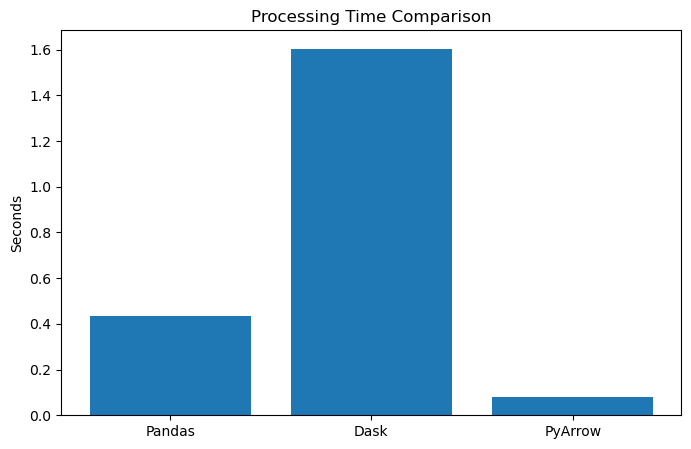

In [9]:
plt.figure(figsize=(8,5))
plt.bar(results["Library"], results["Processing Time (s)"])
plt.title("Processing Time Comparison")
plt.ylabel("Seconds")
plt.show()

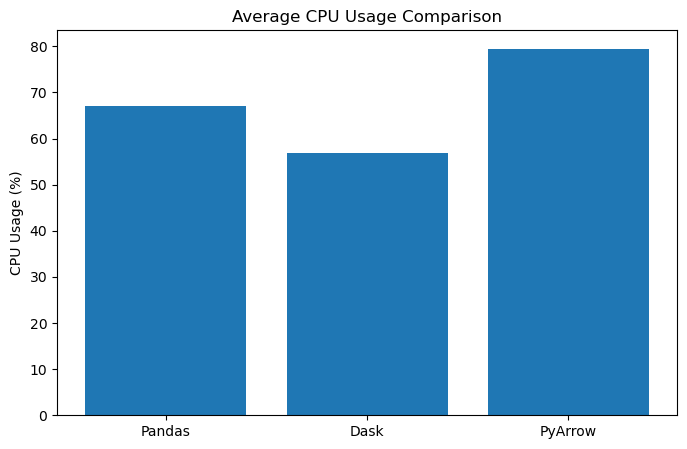

In [10]:
plt.figure(figsize=(8,5))
plt.bar(results["Library"], results["Average CPU (%)"])
plt.title("Average CPU Usage Comparison")
plt.ylabel("CPU Usage (%)")
plt.show()

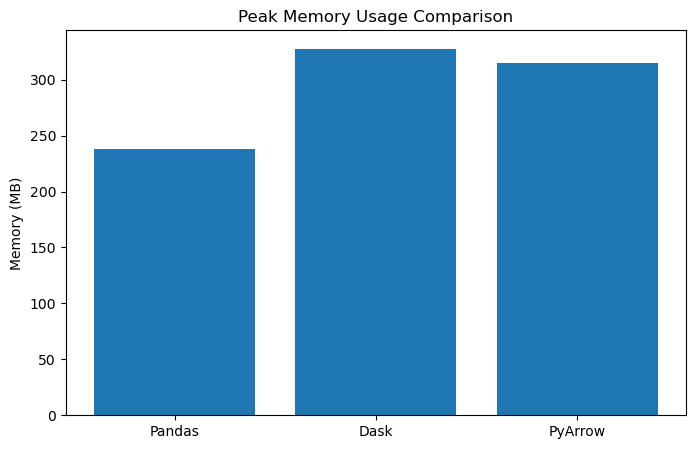

In [11]:
plt.figure(figsize=(8,5))
plt.bar(results["Library"], results["Peak Memory (MB)"])
plt.title("Peak Memory Usage Comparison")
plt.ylabel("Memory (MB)")
plt.show()

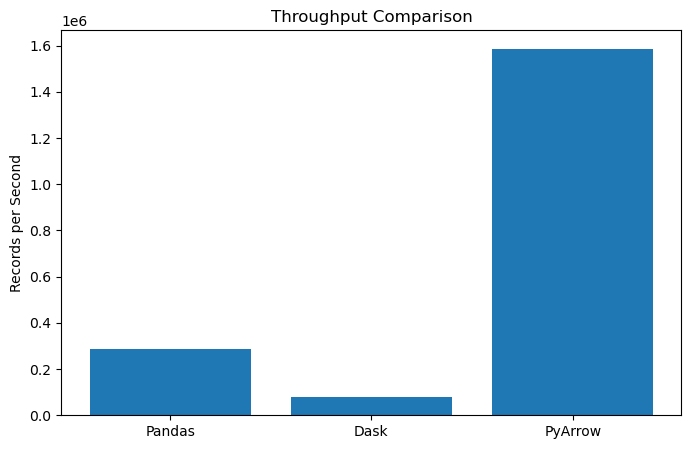

In [12]:
plt.figure(figsize=(8,5))
plt.bar(results["Library"], results["Throughput (records/s)"])
plt.title("Throughput Comparison")
plt.ylabel("Records per Second")
plt.show()